In [2]:
"""
K-Means Clustering 실습 — Iris Dataset
========================================
학습 순서:
  Step 1. 데이터 로드 & 탐색
  Step 2. 전처리 (StandardScaler)
  Step 3. K-Means 모델 학습
  Step 4. 최적 k 탐색 (Elbow + Silhouette)
  Step 5. 결과 시각화
  Step 6. 평가 (Silhouette, ARI)
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

In [3]:
# ─────────────────────────────────────────────
# Step 1. 데이터 로드 & 탐색
# ─────────────────────────────────────────────
iris = load_iris()
X = iris.data        # (150, 4) — 꽃받침/꽃잎 길이·너비
y = iris.target      # 실제 레이블 (평가 시에만 사용)

print("=== Step 1. 데이터 탐색 ===")
print(f"  Shape     : {X.shape}")
print(f"  Features  : {iris.feature_names}")
print(f"  Classes   : {list(iris.target_names)}")
print(f"  Class dist: {np.bincount(y)}")   # 각 클래스 50개

=== Step 1. 데이터 탐색 ===
  Shape     : (150, 4)
  Features  : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
  Classes   : ['setosa', 'versicolor', 'virginica']
  Class dist: [50 50 50]


In [4]:
# ─────────────────────────────────────────────
# Step 2. 전처리
# ─────────────────────────────────────────────
# K-Means는 거리 기반 → 스케일 통일 필수
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 시각화를 위한 PCA 2D 축소 (95.8% 분산 보존)
pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

print("\n=== Step 2. 전처리 ===")
print(f"  스케일 후 평균: {X_scaled.mean(axis=0).round(2)}")
print(f"  스케일 후 표준편차: {X_scaled.std(axis=0).round(2)}")
print(f"  PCA 분산 설명력: {pca.explained_variance_ratio_.sum():.1%}")


=== Step 2. 전처리 ===
  스케일 후 평균: [-0. -0. -0. -0.]
  스케일 후 표준편차: [1. 1. 1. 1.]
  PCA 분산 설명력: 95.8%


In [5]:

# ─────────────────────────────────────────────
# Step 3. K-Means 학습 (k=3)
# ─────────────────────────────────────────────
kmeans = KMeans(
    n_clusters=3,       # 클러스터 수
    init="k-means++",  # 스마트 초기화 (random보다 안정적)
    n_init=10,          # 초기화 10번 반복 후 최선 선택
    max_iter=300,       # 최대 반복 횟수
    random_state=42,
)
labels = kmeans.fit_predict(X_2d)

print("\n=== Step 3. K-Means 학습 ===")
print(f"  클러스터별 샘플 수: {np.bincount(labels)}")
print(f"  최종 Inertia (SSE): {kmeans.inertia_:.2f}")
print(f"  수렴까지 iterations: {kmeans.n_iter_}")


=== Step 3. K-Means 학습 ===
  클러스터별 샘플 수: [53 50 47]
  최종 Inertia (SSE): 115.02
  수렴까지 iterations: 4


In [6]:

# ─────────────────────────────────────────────
# Step 4. 최적 k 탐색
# ─────────────────────────────────────────────
k_range     = range(2, 9)
inertias    = []
silhouettes = []

for k in k_range:
    km  = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    lbl = km.fit_predict(X_2d)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_2d, lbl))

print("\n=== Step 4. 최적 k 탐색 ===")
for k, sil in zip(k_range, silhouettes):
    marker = " <-- best" if k == 3 else ""
    print(f"  k={k}  Silhouette={sil:.3f}{marker}")


=== Step 4. 최적 k 탐색 ===
  k=2  Silhouette=0.615
  k=3  Silhouette=0.509 <-- best
  k=4  Silhouette=0.441
  k=5  Silhouette=0.416
  k=6  Silhouette=0.414
  k=7  Silhouette=0.415
  k=8  Silhouette=0.416


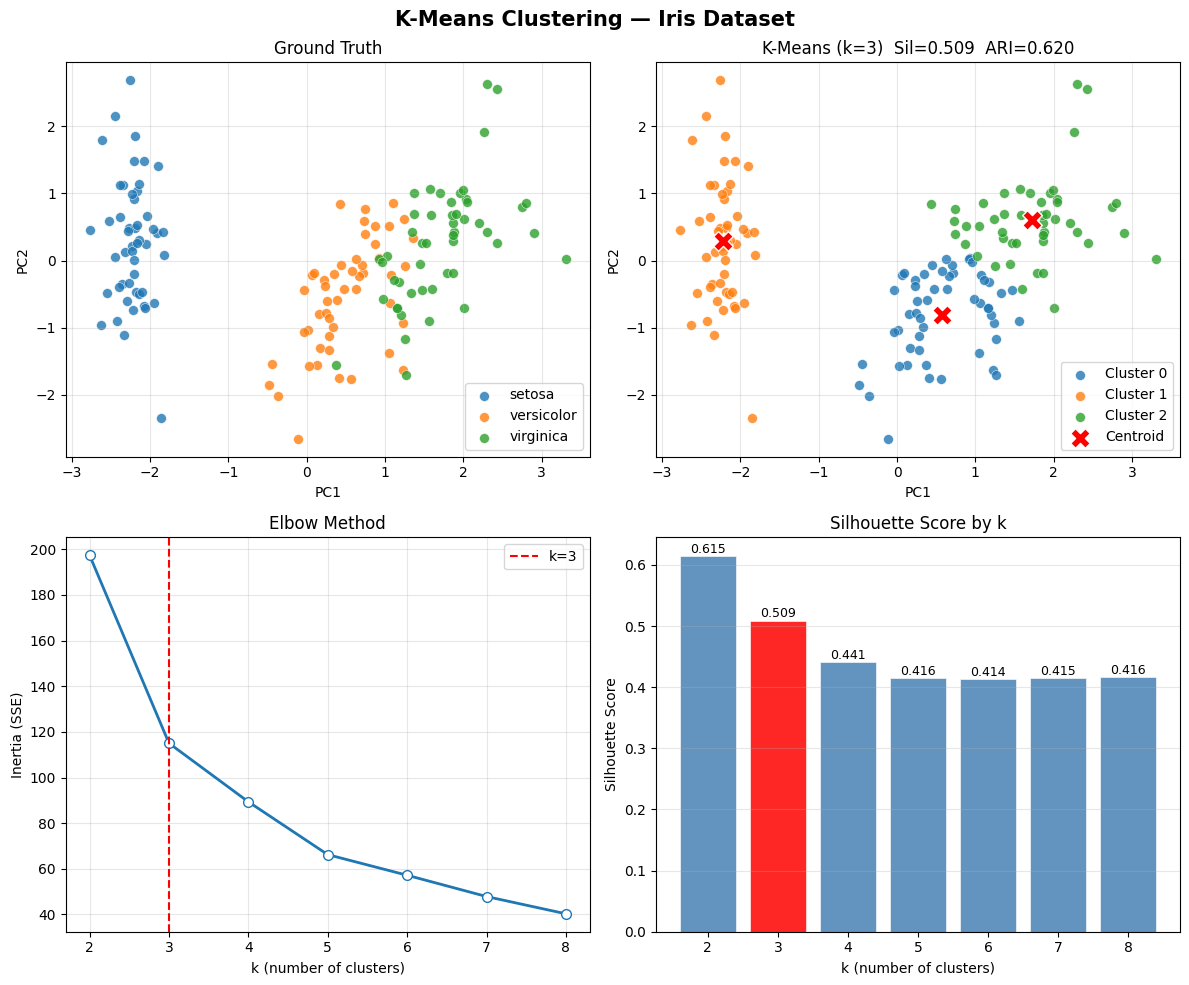


  시각화 저장: kmeans_iris.png

=== Step 6. 평가 결과 ===
  Silhouette Score : 0.5092  (1에 가까울수록 좋음)
  ARI              : 0.6201  (1=실제 레이블과 완전 일치)

  [해석]
  - setosa는 완벽하게 분리됨
  - versicolor/virginica는 경계가 겹쳐 일부 오분류 발생
  - 비지도 학습임에도 ARI 0.62로 실제 클래스를 잘 반영


In [8]:
# ─────────────────────────────────────────────
# Step 5. 시각화
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("K-Means Clustering — Iris Dataset", fontsize=15, fontweight="bold")

COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c"]

# ── 5-1. 실제 레이블 ──────────────────────────
ax = axes[0, 0]
for k in range(3):
    mask = y == k
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=COLORS[k], label=iris.target_names[k],
               s=50, alpha=0.8, edgecolors="white", linewidths=0.4)
ax.set_title("Ground Truth")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
ax.grid(True, alpha=0.3)

# ── 5-2. K-Means 결과 ─────────────────────────
ax = axes[0, 1]
for k in range(3):
    mask = labels == k
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=COLORS[k], label=f"Cluster {k}",
               s=50, alpha=0.8, edgecolors="white", linewidths=0.4)
ax.scatter(kmeans.cluster_centers_[:, 0],
           kmeans.cluster_centers_[:, 1],
           c="red", marker="X", s=200, zorder=5,
           edgecolors="white", linewidths=1, label="Centroid")
sil = silhouette_score(X_2d, labels)
ari = adjusted_rand_score(y, labels)
ax.set_title(f"K-Means (k=3)  Sil={sil:.3f}  ARI={ari:.3f}")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
ax.grid(True, alpha=0.3)

# ── 5-3. Elbow ────────────────────────────────
ax = axes[1, 0]
ax.plot(list(k_range), inertias, "o-",
        linewidth=2, markersize=7, markerfacecolor="white")
ax.axvline(x=3, color="red", linestyle="--", linewidth=1.5, label="k=3")
ax.set_title("Elbow Method")
ax.set_xlabel("k (number of clusters)")
ax.set_ylabel("Inertia (SSE)")
ax.legend()
ax.grid(True, alpha=0.3)

# ── 5-4. Silhouette Score ─────────────────────
ax = axes[1, 1]
bar_colors = ["red" if k == 3 else "steelblue" for k in k_range]
ax.bar(list(k_range), silhouettes, color=bar_colors,
       edgecolor="white", linewidth=0.5, alpha=0.85)
for k, s in zip(k_range, silhouettes):
    ax.text(k, s + 0.005, f"{s:.3f}", ha="center", fontsize=9)
ax.set_title("Silhouette Score by k")
ax.set_xlabel("k (number of clusters)")
ax.set_ylabel("Silhouette Score")
ax.set_xticks(list(k_range))
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()
print("\n  시각화 저장: kmeans_iris.png")


# ─────────────────────────────────────────────
# Step 6. 평가
# ─────────────────────────────────────────────
print("\n=== Step 6. 평가 결과 ===")
print(f"  Silhouette Score : {sil:.4f}  (1에 가까울수록 좋음)")
print(f"  ARI              : {ari:.4f}  (1=실제 레이블과 완전 일치)")
print()
print("  [해석]")
print("  - setosa는 완벽하게 분리됨")
print("  - versicolor/virginica는 경계가 겹쳐 일부 오분류 발생")
print("  - 비지도 학습임에도 ARI 0.62로 실제 클래스를 잘 반영")

# DBSCAN

In [9]:
"""
DBSCAN Clustering 실습 — Iris Dataset
========================================
핵심 개념:
  - Core Point  : 반경 eps 안에 min_samples 이상 이웃
  - Border Point : core point 이웃이지만 본인은 core 아님
  - Noise Point  : 어느 클러스터에도 속하지 않음 (label = -1)

학습 순서:
  Step 1. 데이터 준비
  Step 2. DBSCAN 학습
  Step 3. 포인트 유형 분류 (Core / Border / Noise)
  Step 4. 파라미터 민감도 확인 (eps, min_samples)
  Step 5. 시각화
  Step 6. K-Means와 비교
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

In [10]:
# ─────────────────────────────────────────────
# Step 1. 데이터 준비
# ─────────────────────────────────────────────
iris = load_iris()
X_scaled = StandardScaler().fit_transform(iris.data)

pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)
y    = iris.target

print("=== Step 1. 데이터 준비 ===")
print(f"  Shape: {X_2d.shape}  (PCA 2D, 분산 설명력 {pca.explained_variance_ratio_.sum():.1%})")

=== Step 1. 데이터 준비 ===
  Shape: (150, 2)  (PCA 2D, 분산 설명력 95.8%)


In [11]:
# ─────────────────────────────────────────────
# Step 2. DBSCAN 학습
# ─────────────────────────────────────────────
db = DBSCAN(
    eps=0.6,          # 이웃으로 볼 반경
    min_samples=5,    # core point 조건: 반경 내 최소 이웃 수
)
labels = db.fit_predict(X_2d)

n_clusters = len(set(labels) - {-1})
n_noise    = (labels == -1).sum()

print("\n=== Step 2. DBSCAN 학습 결과 ===")
print(f"  eps={db.eps}, min_samples={db.min_samples}")
print(f"  발견된 클러스터 수 : {n_clusters}")
print(f"  노이즈 포인트 수   : {n_noise} ({n_noise/len(labels):.0%})")
print(f"  클러스터별 샘플 수 : { {k: (labels==k).sum() for k in sorted(set(labels))} }")


=== Step 2. DBSCAN 학습 결과 ===
  eps=0.6, min_samples=5
  발견된 클러스터 수 : 2
  노이즈 포인트 수   : 6 (4%)
  클러스터별 샘플 수 : {-1: 6, 0: 48, 1: 96}


In [12]:
# ─────────────────────────────────────────────
# Step 3. 포인트 유형 분류
# ─────────────────────────────────────────────
# core_sample_indices_ : DBSCAN이 내부적으로 판별한 core point 인덱스
core_mask   = np.zeros(len(X_2d), dtype=bool)
core_mask[db.core_sample_indices_] = True

border_mask = (~core_mask) & (labels != -1)
noise_mask  = labels == -1

print("\n=== Step 3. 포인트 유형 ===")
print(f"  Core   : {core_mask.sum()}개  — 조밀한 중심 역할")
print(f"  Border : {border_mask.sum()}개  — 클러스터 가장자리")
print(f"  Noise  : {noise_mask.sum()}개  — 이상치 처리")


=== Step 3. 포인트 유형 ===
  Core   : 136개  — 조밀한 중심 역할
  Border : 8개  — 클러스터 가장자리
  Noise  : 6개  — 이상치 처리


In [13]:
# ─────────────────────────────────────────────
# Step 4. 파라미터 민감도
# ─────────────────────────────────────────────
print("\n=== Step 4. 파라미터 민감도 ===")
print(f"  {'eps':>5} {'min_s':>6} {'clusters':>9} {'noise%':>7} {'silhouette':>11}")
print("  " + "-" * 42)

param_results = []
for eps in [0.4, 0.6, 0.8, 1.0]:
    for ms in [3, 5, 10]:
        lbl = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_2d)
        nc  = len(set(lbl) - {-1})
        np_ = (lbl == -1).mean() * 100
        sil = silhouette_score(X_2d, lbl) if nc > 1 else float("nan")
        param_results.append((eps, ms, nc, np_, sil))
        mark = " <--" if eps == 0.6 and ms == 5 else ""
        print(f"  {eps:>5} {ms:>6} {nc:>9} {np_:>6.0f}% {sil:>11.3f}{mark}")


=== Step 4. 파라미터 민감도 ===
    eps  min_s  clusters  noise%  silhouette
  ------------------------------------------
    0.4      3         3      7%       0.376
    0.4      5         2     13%       0.482
    0.4     10         3     27%       0.255
    0.6      3         2      3%       0.561
    0.6      5         2      4%       0.571 <--
    0.6     10         2      6%       0.548
    0.8      3         3      1%       0.442
    0.8      5         2      3%       0.558
    0.8     10         2      5%       0.557
    1.0      3         2      1%       0.538
    1.0      5         2      1%       0.538
    1.0     10         2      2%       0.572


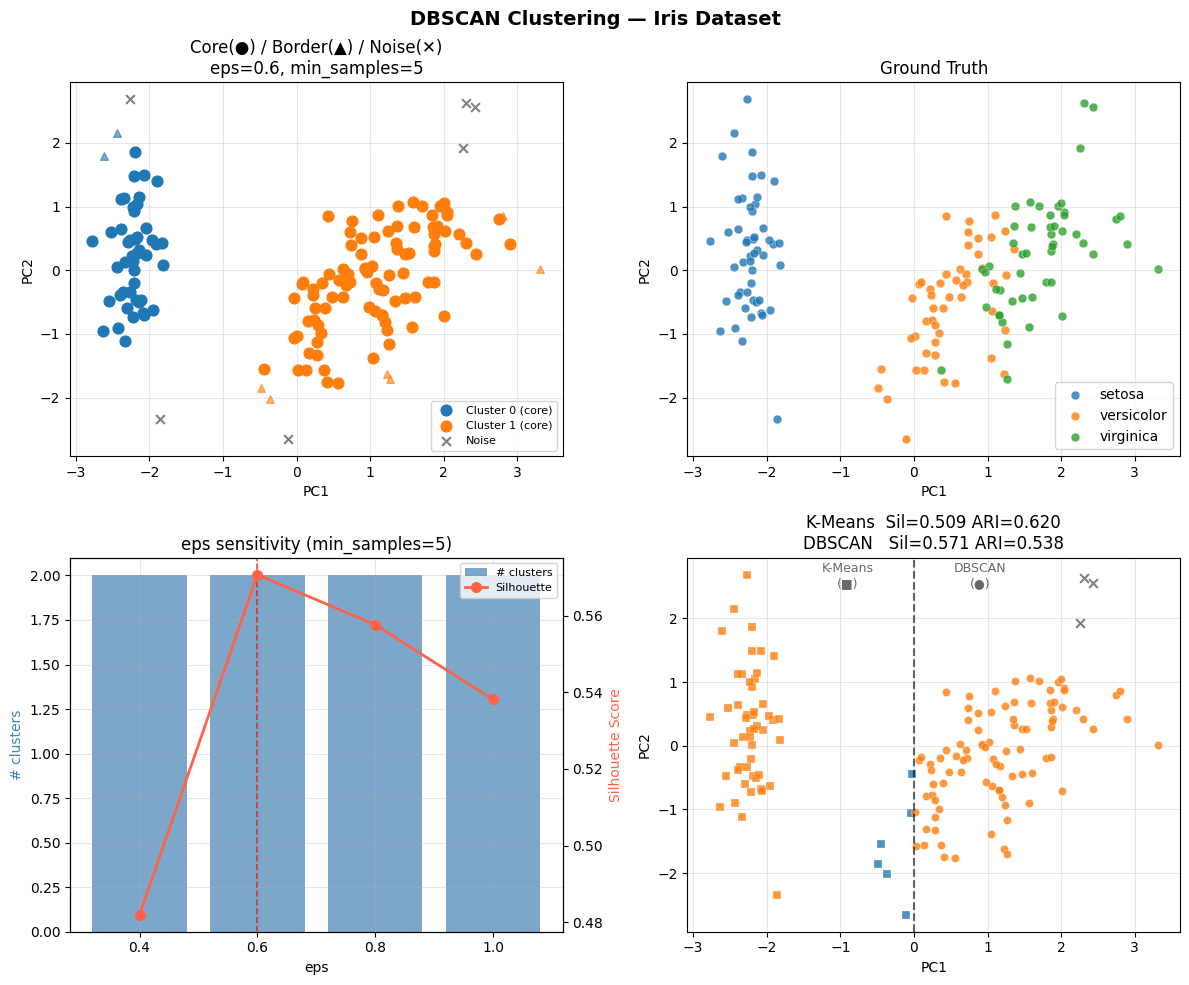


  시각화 저장: dbscan_iris.png

=== Step 6. K-Means vs DBSCAN 비교 ===
                     K-Means     DBSCAN
  클러스터 수                   3          2
  Silhouette           0.509      0.571
  ARI                  0.620      0.538
  노이즈 처리                  없음         6개
  k 사전 지정                 필요        불필요

  [핵심 차이]
  DBSCAN은 이상치를 Noise로 분리 — 클러스터 품질 향상 가능
  단, eps/min_samples 튜닝에 따라 결과가 크게 달라짐


In [15]:
# ─────────────────────────────────────────────
# Step 5. 시각화
# ─────────────────────────────────────────────
CLUSTER_COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("DBSCAN Clustering — Iris Dataset", fontsize=14, fontweight="bold")

# ── 5-1. Core / Border / Noise 구분 ──────────
ax = axes[0, 0]
for k in sorted(set(labels) - {-1}):
    c = CLUSTER_COLORS[k % len(CLUSTER_COLORS)]
    # core
    ax.scatter(X_2d[core_mask & (labels == k), 0],
               X_2d[core_mask & (labels == k), 1],
               c=c, s=60, label=f"Cluster {k} (core)", zorder=3)
    # border
    ax.scatter(X_2d[border_mask & (labels == k), 0],
               X_2d[border_mask & (labels == k), 1],
               c=c, s=30, marker="^", alpha=0.6, zorder=2)

ax.scatter(X_2d[noise_mask, 0], X_2d[noise_mask, 1],
           c="gray", s=40, marker="x", linewidths=1.5,
           label="Noise", zorder=4)
ax.set_title(f"Core(●) / Border(▲) / Noise(✕)\neps={db.eps}, min_samples={db.min_samples}")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── 5-2. Ground Truth 비교 ────────────────────
ax = axes[0, 1]
for k in range(3):
    mask = y == k
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=CLUSTER_COLORS[k], label=iris.target_names[k],
               s=40, alpha=0.8, edgecolors="white", linewidths=0.3)
ax.set_title("Ground Truth")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(); ax.grid(True, alpha=0.3)

# ── 5-3. eps 변화에 따른 클러스터 수 ─────────
ax = axes[1, 0]
eps_list  = [r[0] for r in param_results if r[1] == 5]
nc_list   = [r[2] for r in param_results if r[1] == 5]
sil_list  = [r[4] for r in param_results if r[1] == 5]

ax2 = ax.twinx()
ax.bar([str(e) for e in eps_list], nc_list,
       color="steelblue", alpha=0.7, label="# clusters")
ax2.plot([str(e) for e in eps_list], sil_list,
         "o-", color="tomato", linewidth=2, markersize=7, label="Silhouette")
ax.axvline(x="0.6", color="red", linestyle="--", linewidth=1.2, alpha=0.7)
ax.set_title("eps sensitivity (min_samples=5)")
ax.set_xlabel("eps"); ax.set_ylabel("# clusters", color="steelblue")
ax2.set_ylabel("Silhouette Score", color="tomato")
lines1, lb1 = ax.get_legend_handles_labels()
lines2, lb2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, lb1 + lb2, fontsize=8)
ax.grid(True, alpha=0.3)

# ── 5-4. K-Means vs DBSCAN 나란히 ────────────
ax = axes[1, 1]
km_labels = KMeans(n_clusters=3, n_init=10, random_state=42).fit_predict(X_2d)

# 왼쪽 절반: K-Means, 오른쪽 절반: DBSCAN  (x 기준 분할)
split = X_2d[:, 0].mean()

for k in range(3):
    mask = (km_labels == k) & (X_2d[:, 0] < split)
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=CLUSTER_COLORS[k], s=35, alpha=0.8,
               marker="s", edgecolors="white", linewidths=0.3)

for k in sorted(set(labels) - {-1}):
    mask = (labels == k) & (X_2d[:, 0] >= split)
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=CLUSTER_COLORS[k], s=35, alpha=0.8,
               marker="o", edgecolors="white", linewidths=0.3)
mask_noise = noise_mask & (X_2d[:, 0] >= split)
ax.scatter(X_2d[mask_noise, 0], X_2d[mask_noise, 1],
           c="gray", s=40, marker="x", linewidths=1.5)

ax.axvline(x=split, color="black", linestyle="--", linewidth=1.5, alpha=0.6)
ax.text(split - 0.9, X_2d[:, 1].max() - 0.2, "K-Means\n(■)",
        fontsize=9, ha="center", color="dimgray")
ax.text(split + 0.9, X_2d[:, 1].max() - 0.2, "DBSCAN\n(●)",
        fontsize=9, ha="center", color="dimgray")

km_sil = silhouette_score(X_2d, km_labels)
db_sil = silhouette_score(X_2d, labels)
km_ari = adjusted_rand_score(y, km_labels)
db_ari = adjusted_rand_score(y, labels)
ax.set_title(f"K-Means  Sil={km_sil:.3f} ARI={km_ari:.3f}\n"
             f"DBSCAN   Sil={db_sil:.3f} ARI={db_ari:.3f}")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("\n  시각화 저장: dbscan_iris.png")


# ─────────────────────────────────────────────
# Step 6. K-Means vs DBSCAN 평가 요약
# ─────────────────────────────────────────────
print("\n=== Step 6. K-Means vs DBSCAN 비교 ===")
print(f"  {'':15} {'K-Means':>10} {'DBSCAN':>10}")
print(f"  {'클러스터 수':15} {'3':>10} {n_clusters:>10}")
print(f"  {'Silhouette':15} {km_sil:>10.3f} {db_sil:>10.3f}")
print(f"  {'ARI':15} {km_ari:>10.3f} {db_ari:>10.3f}")
print(f"  {'노이즈 처리':15} {'없음':>10} {f'{n_noise}개':>10}")
print(f"  {'k 사전 지정':15} {'필요':>10} {'불필요':>10}")
print()
print("  [핵심 차이]")
print("  DBSCAN은 이상치를 Noise로 분리 — 클러스터 품질 향상 가능")
print("  단, eps/min_samples 튜닝에 따라 결과가 크게 달라짐")